**Ariel Pan, Daniel Lyu**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 1: Hebbian Learning

#### Week 4: Decoding class labels from Competitive Hebbian Network activations

You will use single layer artificial neural networks to **decode** (i.e. predict) the class label corresponding to each MNIST and CIFAR-10 sample **encoded** (i.e. processed) by your Competitive Hebbian Network. This will take advantage of the Competitive Hebbian Network weights that you saved off last week. Once you obtain the Competitive Hebbian Network activations, you will predict the class labels and compute the classification accuracy for each dataset obtained by this **encoder-decoder** neural network architecture.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

## Task 9: Decode class labels from Hebbian network activations

The goal of this task is to train your linear and nonlinear decoder networks to classify MNIST digits (then later on CIFAR-10 classes) based on the Hebbian activations to each sample.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import sys

sys.path.append("/content/drive/MyDrive/ColabNotebooks/project1")

In [4]:
from image_datasets import get_dataset, train_val_split
from decoder_nets import LinearDecoder, NonlinearDecoder
from hebb_net import HebbNet

### 9a. Preparing decoder inputs

In the cell below:
1. Load MNIST in train/test/validation samples. Use the default validation split.
2. Process them with your Competitive Hebbian Network (i.e. compute their corresponding netIn values) to get the input for your decoders.

**Tips:**
- Your Hebbian network constructor has a keyword argument that you can use to load wts from a previously trained network. You should **NOT** retrain your Hebbian network here!
- When creating your Hebbian network object, remember to build it with the same hyperparameters as you did last week (e.g. number of neurons, `k` value).

In [33]:
x_train_full, y_train_full, x_test, y_test = get_dataset('mnist', norm_method='center', flatten=True, verbose=False)
x_train, y_train, x_val, y_val = train_val_split(x_train_full, y_train_full, prop_val=0.1)

print("train:", x_train.shape, y_train.shape)
print("val:  ", x_val.shape, y_val.shape)
print("test: ", x_test.shape, y_test.shape)

M = x_train.shape[1]
H = 2000
k = 6
inhib_value = -0.4
saved_wts_path = "/content/drive/MyDrive/project1/export/wts.npy"

hebb = HebbNet(
    num_features=M,
    num_neurons=H,
    k=k,
    inhib_value=inhib_value,
    load_wts=True,
    saved_wts_path=saved_wts_path
)

train_netIn = tf.cast(hebb.net_in(x_train), tf.float32)
val_netIn   = tf.cast(hebb.net_in(x_val), tf.float32)
test_netIn  = tf.cast(hebb.net_in(x_test), tf.float32)

y_train = tf.cast(y_train, tf.int32)
y_val   = tf.cast(y_val, tf.int32)
y_test  = tf.cast(y_test, tf.int32)

print("train_netIn:", train_netIn.shape)
print("val_netIn:  ", val_netIn.shape)
print("test_netIn: ", test_netIn.shape)

train: (54000, 784) (54000,)
val:   (6000, 784) (6000,)
test:  (10000, 784) (10000,)
Loaded stored wts.
train_netIn: (54000, 2000)
val_netIn:   (6000, 2000)
test_netIn:  (10000, 2000)


### 9b. Train linear decoder (MNIST)

Train your softmax classifier on the Hebbian network `net_in` activations obtained from processing the MNIST training set. Keep default hyperparameters except:
1. Play around with the mini-batch size. Try starting with `256` and adjust as needed.
2. Feel free to change the `patience` depending on your patience. A patience around `3-7` should produce good results.
3. Try a learning rate decay patience of `3-5` with max decays set to `3-4`. Adjust as needed.

#### Guidelines

- **DO NOT COPY AND PASTE HYPERPARAMETERS FROM THE IRIS TEST CODE CELLS!** They will not work well for MNIST 🙄
- Training should be fairly quick (no more than a few minutes).
- **Remember:** you are **NOT** training the linear classifier **on MNIST** — you are training it on the `net_in` values produced by the Competitive Hebbian Network that you trained above!

Your results should be comparable to that of the linear decoder trained on the MNIST samples directly.

In [14]:
train_netIn = tf.cast(train_netIn, tf.float32)
val_netIn   = tf.cast(val_netIn, tf.float32)
test_netIn  = tf.cast(test_netIn, tf.float32)
y_train = tf.cast(y_train, tf.int32)
y_val   = tf.cast(y_val, tf.int32)
y_test  = tf.cast(y_test, tf.int32)

In [15]:
decoder = LinearDecoder(input_feats_shape=(H,), C=10)
decoder.compile(loss='cross_entropy', lr=1e-3, print_summary=False)

train_loss_hist, val_loss_hist, val_acc_hist, e = decoder.fit(
    train_netIn, y_train,
    x_val=val_netIn, y_val=y_val,
    batch_size=256,
    max_epochs=500,
    val_every=1,
    print_every=10,
    verbose=True,
    patience=5,
    lr_patience=4,
    lr_decay_factor=0.5,
    lr_max_decays=4
)

test_acc, test_loss = decoder.evaluate(test_netIn, y_test)
print("test_acc:", test_acc)
print("test_loss:", test_loss)

Epoch 1/500 | Time : 6.43 s | train_loss: 0.4612 | val_loss: 0.3087 | val_acc: 0.9115

Epoch 2/500 | Time : 3.18 s | train_loss: 0.3691 | val_loss: 0.3008 | val_acc: 0.9115

Epoch 3/500 | Time : 3.20 s | train_loss: 0.3671 | val_loss: 0.2932 | val_acc: 0.9153

Epoch 4/500 | Time : 4.21 s | train_loss: 0.3670 | val_loss: 0.3052 | val_acc: 0.9118

Epoch 5/500 | Time : 3.25 s | train_loss: 0.3574 | val_loss: 0.2809 | val_acc: 0.9172

Epoch 6/500 | Time : 3.21 s | train_loss: 0.3568 | val_loss: 0.2789 | val_acc: 0.9205

Epoch 7/500 | Time : 3.47 s | train_loss: 0.3469 | val_loss: 0.2873 | val_acc: 0.9192

Epoch 8/500 | Time : 3.75 s | train_loss: 0.3502 | val_loss: 0.2754 | val_acc: 0.9205

Epoch 9/500 | Time : 3.38 s | train_loss: 0.3453 | val_loss: 0.2746 | val_acc: 0.9249

Epoch 10/500 | Time : 3.44 s | train_loss: 0.3482 | val_loss: 0.2947 | val_acc: 0.9162

Epoch 11/500 | Time : 4.10 s | train_loss: 0.3326 | val_loss: 0.2792 | val_acc: 0.9227

Epoch 12/500 | Time : 3.16 s | train_loss

### 9c. Analyze Linear Decoder performance

Create a well-labeled plot showing the training and validation loss over epochs. Place the test accuracy of the linear classifier in your plot title.

**Note:** Because the initial training and validation losses are so large compared to the final values, plotting all the values may obscure details about the eventual loss curve. I would suggest trimming out the training and validation loss values for the first few epochs to highlight the long-term trend.

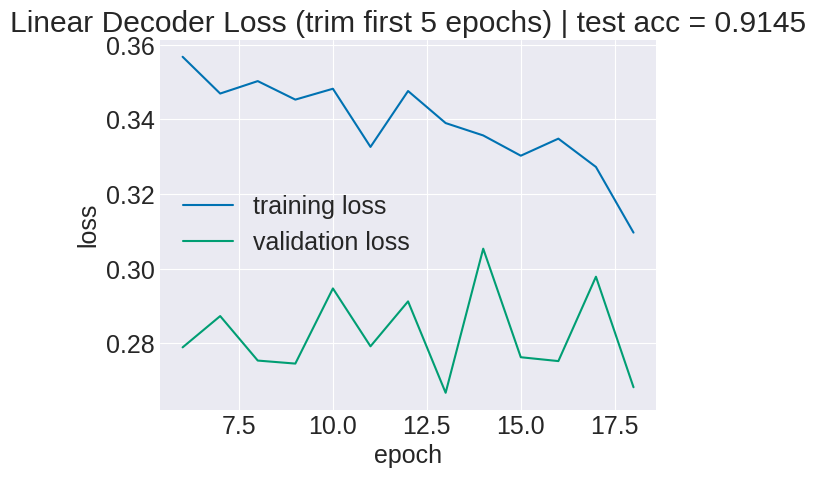

In [16]:
train_loss_hist = train_loss_hist
val_loss_hist   = val_loss_hist

train_loss = np.array(train_loss_hist, dtype=float)
val_loss   = np.array(val_loss_hist, dtype=float)

trim = 5

test_acc, _ = decoder.evaluate(test_netIn, y_test)

plt.figure()
plt.plot(np.arange(1+trim, len(train_loss)+1), train_loss[trim:], label='training loss')
plt.plot(np.arange(1+trim, len(val_loss)+1),   val_loss[trim:],   label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title(f'Linear Decoder Loss (trim first {trim} epochs) | test acc = {test_acc:.4f}')
plt.legend()
plt.show()

### 9d. Train nonlinear decoder (MNIST)

Repeat what you did for the linear classifier with the nonlinear classifier.

**Note there is one additional step:** Once you get the Hebbian network `net_in` values for the train/validation/test sets, the nonlinear decoding network proposed by Krotov & Hopfield (2019) assumes that the Hebbian network `net_in` values ($h_{ij}$) that serve as the input to the decoder are transformed by the following activation function:

$$x_{ij} = max(h_{ij}, 0)^n$$

where $h_{ij}$ are the Hebbian network `net_in` values. In other words, apply ReLU to the `net_in` values then raise the result to the power `n`. By default, we assume that the hyperparameter $n=4.0$.

You may implement this preprocessing step in the `preprocess_nonlinear` function in `image_datasets.py`. **This additional ReLU step needs to be performed on the `net_in` values representing each of the decoder train, validation, AND test sets!!**

**For full credit** your goal is to have your encoder-decoder system achieve either validation or test accuracy ≥ 97.5%. If this goal is not met, there will be point reductions, depending on how far below your system is from this target.

Here are suggested non-default hyperparameter values:
- patience: 5-9
- learning rate patience: below the regular patience, 3-5
- maximum learning rate decays: 3-4
- loss exponent: the default should do well, though you may be able to do a bit better with an exponent of `5.0`.

**Notes, reminders, and guidelines:**
- Remember that the nonlinear decoder uses the $L^p$ loss!
- Training should take longer than your linear decoder, but not a lot longer (rough estimate 10-20 minutes).

In [17]:
from image_datasets import preprocess_nonlinear

In [25]:
n = 5.0
train_nl = preprocess_nonlinear(train_netIn, n)
val_nl   = preprocess_nonlinear(val_netIn, n)
test_nl  = preprocess_nonlinear(test_netIn, n)

nonlin = NonlinearDecoder(input_feats_shape=(H,), C=10, wt_scale=0.1, beta=0.0025, loss_exp=4.0)
nonlin.compile(loss='lp', lr=1e-3, print_summary=False)

train_loss_nl, val_loss_nl, val_acc_nl, e_nl = nonlin.fit(
    train_nl, y_train,
    x_val=val_nl, y_val=y_val,
    batch_size=256,
    max_epochs=500,
    val_every=1,
    print_every=10,
    verbose=True,
    patience=7,
    lr_patience=4,
    lr_decay_factor=0.5,
    lr_max_decays=4
)

test_acc_nl, test_loss_nl = nonlin.evaluate(test_nl, y_test)

Epoch 1/500 | Time : 3.09 s | train_loss: 1.1424 | val_loss: 0.3212 | val_acc: 0.8599

Epoch 2/500 | Time : 4.13 s | train_loss: 0.2403 | val_loss: 0.1537 | val_acc: 0.9452

Epoch 3/500 | Time : 4.38 s | train_loss: 0.1485 | val_loss: 0.1145 | val_acc: 0.9565

Epoch 4/500 | Time : 4.25 s | train_loss: 0.1155 | val_loss: 0.0931 | val_acc: 0.9625

Epoch 5/500 | Time : 4.17 s | train_loss: 0.0946 | val_loss: 0.0844 | val_acc: 0.9662

Epoch 6/500 | Time : 4.53 s | train_loss: 0.0867 | val_loss: 0.0800 | val_acc: 0.9686

Epoch 7/500 | Time : 3.01 s | train_loss: 0.0762 | val_loss: 0.0767 | val_acc: 0.9696

Epoch 8/500 | Time : 3.17 s | train_loss: 0.0684 | val_loss: 0.0705 | val_acc: 0.9704

Epoch 9/500 | Time : 4.73 s | train_loss: 0.0634 | val_loss: 0.0672 | val_acc: 0.9716

Epoch 10/500 | Time : 3.04 s | train_loss: 0.0599 | val_loss: 0.0663 | val_acc: 0.9714

Epoch 11/500 | Time : 3.10 s | train_loss: 0.0538 | val_loss: 0.0631 | val_acc: 0.9730

Epoch 12/500 | Time : 3.18 s | train_loss

In [30]:
test_acc_nl, test_loss_nl = nonlin.evaluate(test_nl, y_test)

In [31]:
print('test accuracy: ', test_acc_nl, 'test loss: ', test_loss_nl)

test accuracy:  0.9764623397435898 test loss:  0.052562896886988765


### 9e: Analyze Nonlinear Decoder performance (MNIST)

Create a well-labeled plot showing the training and validation loss over training epochs. Place the accuracy of the nonlinear classifier on the test set in your plot title.

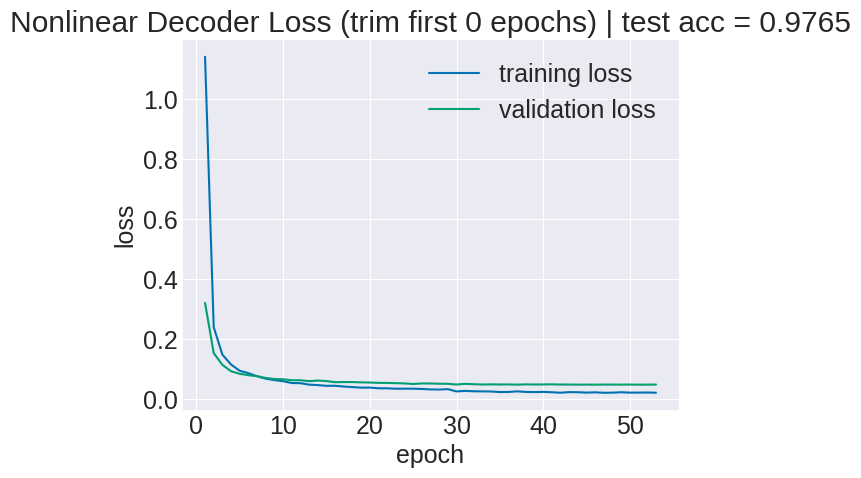

In [32]:
train_loss_hist = train_loss_nl
val_loss_hist   = val_loss_nl

train_loss = np.array(train_loss_hist, dtype=float)
val_loss   = np.array(val_loss_hist, dtype=float)

trim = 0

plt.figure()
plt.plot(np.arange(1+trim, len(train_loss)+1), train_loss[trim:], label='training loss')
plt.plot(np.arange(1+trim, len(val_loss)+1),   val_loss[trim:],   label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title(f'Nonlinear Decoder Loss (trim first {trim} epochs) | test acc = {test_acc_nl:.4f}')
plt.legend()
plt.show()

### 9f. Train linear decoder (CIFAR-10)

Train the linear decoder on the `net_in` Hebbian network values obtained to the CIFAR-10 dataset to decode the class labels. Repeat your data loading and training protocols.

**Notes:**
- If you configured your Hebbian network as suggested for CIFAR-10, with 2nd place neurons being inhibited (`k=2`), set `k=2` below when creating and loading your Hebbian network below.
- The same hyperparameters you used to decode MNIST should work fine here too.

In [35]:
x_train_full, y_train_full, x_test, y_test = get_dataset('cifar10', norm_method='center', flatten=True, verbose=False)
x_train, y_train, x_val, y_val = train_val_split(x_train_full, y_train_full, prop_val=0.1)

M = x_train.shape[1]
H = 2000
k = 2
inhib_value = -0.4
saved_wts_path = "/content/drive/MyDrive/project1/export/wts_cifar.npy"

hebb_cifar = HebbNet(
    num_features=M,
    num_neurons=H,
    k=k,
    inhib_value=inhib_value,
    load_wts=True,
    saved_wts_path=saved_wts_path
)

train_netIn_cifar = tf.cast(hebb_cifar.net_in(x_train), tf.float32)
val_netIn_cifar   = tf.cast(hebb_cifar.net_in(x_val), tf.float32)
test_netIn_cifar  = tf.cast(hebb_cifar.net_in(x_test), tf.float32)

y_train = tf.cast(y_train, tf.int32)
y_val   = tf.cast(y_val, tf.int32)
y_test  = tf.cast(y_test, tf.int32)

decoder_cifar = LinearDecoder(input_feats_shape=(H,), C=10)
decoder_cifar.compile(loss='cross_entropy', lr=1e-3, print_summary=False)

train_loss_cifar, val_loss_cifar, val_acc_cifar, e_cifar = decoder_cifar.fit(
    train_netIn_cifar, y_train,
    x_val=val_netIn_cifar, y_val=y_val,
    batch_size=256,
    max_epochs=500,
    val_every=1,
    print_every=10,
    verbose=True,
    patience=5,
    lr_patience=4,
    lr_decay_factor=0.5,
    lr_max_decays=4
)

test_acc_cifar, test_loss_cifar = decoder_cifar.evaluate(test_netIn_cifar, y_test)
print(test_acc_cifar, test_loss_cifar)

Loaded stored wts.
Epoch 1/500 | Time : 3.37 s | train_loss: 2.2009 | val_loss: 2.0358 | val_acc: 0.2985

Epoch 2/500 | Time : 3.04 s | train_loss: 2.0366 | val_loss: 1.9640 | val_acc: 0.3335

Epoch 3/500 | Time : 2.65 s | train_loss: 2.0285 | val_loss: 1.9798 | val_acc: 0.3151

Epoch 4/500 | Time : 2.72 s | train_loss: 2.0124 | val_loss: 1.9831 | val_acc: 0.3223

Epoch 5/500 | Time : 2.96 s | train_loss: 1.9950 | val_loss: 1.9642 | val_acc: 0.3147

Epoch 6/500 | Time : 3.24 s | train_loss: 2.0085 | val_loss: 2.0018 | val_acc: 0.3075
Learning rate decayed from 0.001000 to 0.000500.
 | LR decayed. Total decays: 1
Epoch 7/500 | Time : 2.79 s | train_loss: 1.8585 | val_loss: 1.8776 | val_acc: 0.3458

Epoch 8/500 | Time : 2.77 s | train_loss: 1.8513 | val_loss: 1.8316 | val_acc: 0.3694

Epoch 9/500 | Time : 2.95 s | train_loss: 1.8597 | val_loss: 1.8445 | val_acc: 0.3580

Epoch 10/500 | Time : 3.34 s | train_loss: 1.8648 | val_loss: 1.8931 | val_acc: 0.3452

Epoch 11/500 | Time : 2.65 s | 

Make a well-labeled plot showing the training and validation loss over the course of training. Place the test set accuracy in the plot title.

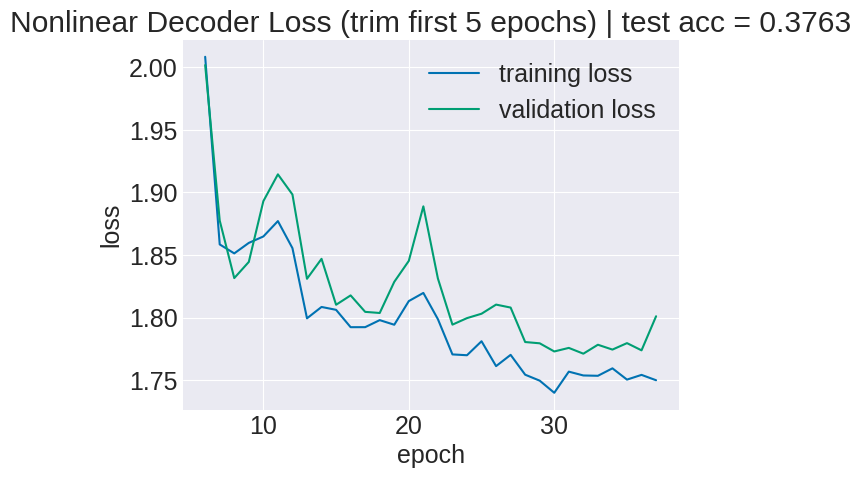

In [40]:
train_loss_hist = train_loss_cifar
val_loss_hist   = val_loss_cifar

train_loss = np.array(train_loss_hist, dtype=float)
val_loss   = np.array(val_loss_hist, dtype=float)

trim = 5

plt.figure()
plt.plot(np.arange(1+trim, len(train_loss)+1), train_loss[trim:], label='training loss')
plt.plot(np.arange(1+trim, len(val_loss)+1),   val_loss[trim:],   label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title(f'Nonlinear Decoder Loss (trim first {trim} epochs) | test acc = {test_acc_cifar:.4f}')
plt.legend()
plt.show()

### 9g. Train nonlinear decoder (CIFAR-10)

Train the nonlinear decoder on the `net_in` Hebbian network values obtained to the CIFAR-10 dataset to decode the class labels. Repeat your data loading and training protocols.

If you configured your Hebbian network as suggested for CIFAR-10, with 2nd place neurons being inhibited (`k=2`), set `k=2` below when creating and loading your Hebbian network below.

**Suggested non-default hyperparameters:**
- Power `n` to raise Hebbian activations when applying ReLU: `2.0`
- Loss exponent: `4.0`
- patience: 5-9
- learning rate patience: below the regular patience, 3-5
- maximum learning rate decays: 3-4

**For full credit** your goal is to have your encoder-decoder system achieve either validation or test accuracy ≥ 47%. If this goal is not met, there will be point reductions, depending on how far below your system is from this target.

In [41]:
n = 2.0
train_cifar = preprocess_nonlinear(train_netIn_cifar, n)
val_cifar   = preprocess_nonlinear(val_netIn_cifar, n)
test_cifar  = preprocess_nonlinear(test_netIn_cifar, n)

nonlin_cifar = NonlinearDecoder(input_feats_shape=(H,), C=10, wt_scale=0.1, beta=0.0025, loss_exp=4.0)
nonlin_cifar.compile(loss='lp', lr=1e-3, print_summary=False)

train_loss_cifar, val_loss_cifar, val_acc_cifar, e_cifar = nonlin_cifar.fit(
    train_cifar, y_train,
    x_val=val_cifar, y_val=y_val,
    batch_size=256,
    max_epochs=500,
    val_every=1,
    print_every=10,
    verbose=True,
    patience=7,
    lr_patience=4,
    lr_decay_factor=0.5,
    lr_max_decays=4
)

test_acc_cifar, test_loss_cifar = nonlin_cifar.evaluate(test_cifar, y_test)

Epoch 1/500 | Time : 2.63 s | train_loss: 0.5550 | val_loss: 0.4896 | val_acc: 0.3331

Epoch 2/500 | Time : 3.12 s | train_loss: 0.4779 | val_loss: 0.4662 | val_acc: 0.3618

Epoch 3/500 | Time : 3.20 s | train_loss: 0.4588 | val_loss: 0.4525 | val_acc: 0.3840

Epoch 4/500 | Time : 2.87 s | train_loss: 0.4465 | val_loss: 0.4452 | val_acc: 0.3936

Epoch 5/500 | Time : 2.72 s | train_loss: 0.4413 | val_loss: 0.4398 | val_acc: 0.3978

Epoch 6/500 | Time : 2.97 s | train_loss: 0.4354 | val_loss: 0.4349 | val_acc: 0.4012

Epoch 7/500 | Time : 3.29 s | train_loss: 0.4298 | val_loss: 0.4323 | val_acc: 0.4119

Epoch 8/500 | Time : 2.67 s | train_loss: 0.4251 | val_loss: 0.4291 | val_acc: 0.4111

Epoch 9/500 | Time : 2.68 s | train_loss: 0.4232 | val_loss: 0.4258 | val_acc: 0.4213

Epoch 10/500 | Time : 2.57 s | train_loss: 0.4226 | val_loss: 0.4235 | val_acc: 0.4223

Epoch 11/500 | Time : 3.75 s | train_loss: 0.4209 | val_loss: 0.4228 | val_acc: 0.4147

Epoch 12/500 | Time : 2.59 s | train_loss

Make a well-labeled plot showing the training and validation loss over the course of training. Place the test set accuracy in the plot title.

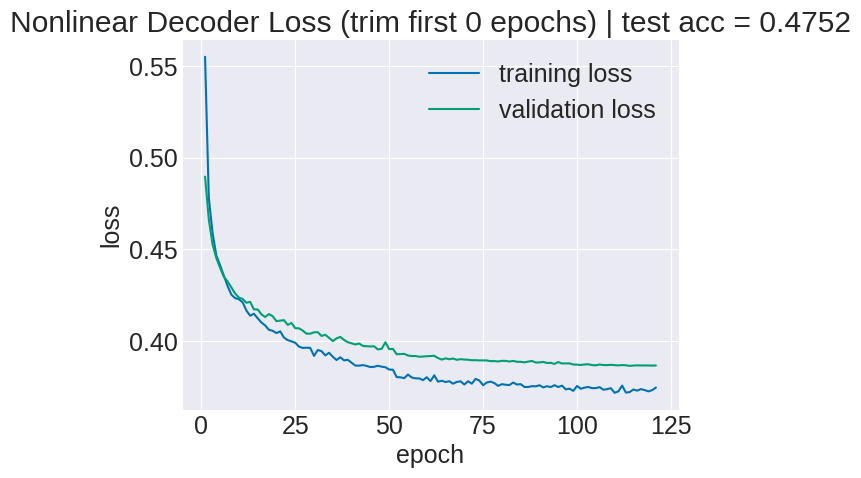

In [42]:
train_loss_hist = train_loss_cifar
val_loss_hist   = val_loss_cifar

train_loss = np.array(train_loss_hist, dtype=float)
val_loss   = np.array(val_loss_hist, dtype=float)

trim = 0

plt.figure()
plt.plot(np.arange(1+trim, len(train_loss)+1), train_loss[trim:], label='training loss')
plt.plot(np.arange(1+trim, len(val_loss)+1),   val_loss[trim:],   label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title(f'Nonlinear Decoder Loss (trim first {trim} epochs) | test acc = {test_acc_cifar:.4f}')
plt.legend()
plt.show()

### 9h. Questions

**Question 14:** Describe one specific case (*linear or nonlinear decoder paired with MNIST or CIFAR-10*)where the learning rate decay made a substantial difference in the validation accuracy that your encoder-decoder system achieved. What results would you have achieved with and without this technique? *You should be able to answer this question based on your training print outs; you do NOT need to retrain your networks to answer this question.*

**Answer 14:** It happens at linear decoder training for CIFAR-10, the first lr decay (between epoch 6 and epoch 7). With the technique, validation accuracy improves from 0.31 to 0.35. Without the technique, it's very likely that the validation accuracy will stuck at around 0.3 until the early stopping is triggered, since from epoch 3 to epoch 6 the val loss is increasing and the val acc is gradually decreasing.

## Extensions

### General guidelines

1. Never integrate extensions into your base project so that they change the expected behavior of core functions. If your extension changes the core design/behavior, no problem, duplicate your working base project and add features from there.
2. Check the rubric to keep in mind how extensions on this project will be graded.
3. While I may consult your code and "written log" of what you did, **I am grading your extensions based on what you present in your 3-5 min video.**
3. I suggest documenting your explorations in a "log" or "lab notebook" style (i.e. documenting your thought/progression/discovery/learning process). I'm not grading your writing, so you can keep it succinct. **Whatever is most useful to you to remember what you did.**
4. I suggest taking a hypothesis driven approach. For example "I was curious about X so I explored Y. I found Z, which was not what I expected because..., so then tried A..."
5. Make plots to help showcase your results.
6. **More is not necessarily better.** Generally, a small number of "in-depth" extensions count for more than many "shallow" extensions.

### AI guidelines

You may use AI in mostly any capacity for extensions. However, keep in mind:
1. There is no need to use AI at all!
2. You are welcome to use AI as a tool (e.g. automate something that is tedious, help you get unstuck, etc.). However, you should be coding, you should be thinking, you should be writing, you should be creating. If you are spending most (or even close to most) of your time typing into a chatbot and copy-pasting, you have probably gone too far with AI use.
3. I don't find large volumes of AI generated code/text/plots to be particularly impressive and you risk losing my interest while grading. Remember: I'm grading your extensions based on your video presentation. **More is not necessarily better.**

### Video guidelines

1. Please try to keep your video to 5 minutes (*I have other projects to grade!*). If you turn in a longer video, I make no promise that I will watch more than 5 minutes.
2. Your screen should be shared as you show me what you did. A live video of your face should also appear somewhere on the screen (e.g. picture-in-picture overlay / split screen).
3. Your partner should join you for the video and take turns talking, but, if necessary, it is fine to have one team member present during the record the video.
4. Do not simply read text from your notebook, do not read from a prepared script. I am not grading how polished your video presentation is (see extension grading criteria on rubric).
5. I am looking for original and creative explorations sparked by your curiosity/interest/passion in a topic. This should be apparent in your video.
6. Be natural,, don't feel the need to impress me with fancy language. If it is helpful, imagine that we are talking one-on-one about your extension. Tell me what you did :)

### Extension ideas

#### 1. Compare encoder-decoder model to end-to-end training

Compare your results from this project to other end-to-end artificial neural networks trained directly on MNIST or CIFAR-10 (e.g. MLPs, CNNs). I would suggest keeping hyperparameters constant for a fair comparison. There is a lot to explore here! Here are a few questions to examine:
- Are there differences in how rapidly the systems learn their inputs (e.g. number of training epochs needed to achieve "good" accuracy on the validation set)?
- What test accuracy is achievable?
- How does the total training time compare?

In your analysis, account for the complexity/number of parameters in each system.

#### 2. Hyperparameter explorations

Explore how the hyperparameters affect classification accuracy. Can you improve upon the results from the base project?

- Remember, the encoder has numerous hyperparameters to experiment with. For example, remember that you can also control the dimension of the "embedding" performed by the Hebbian network (i.e. number of neurons in the net), the amount of inhibition, etc.
- Use a grid or random search for encoder and/decoder networks to optimize performance.

#### 3. Use your CS 343 Softmax network as the linear decoder

This will require a few updates to support the Adam optimizer (that you implemented in the CS 343 CNN project) and validation sets.

Copy `softmax_layer.py` from your CS343 MLP project to your working directory. Also copy `optimizer.py` from your CS343 CNN project.

Make the following changes to `fit()` in `softmax_layer.py`:
1. Switch your optimizer from SGD to Adam. This will involve creating two `Adam` objects: one for the weights, one for the bias. Also, be sure to set the Adam learning rate based on the value passed into `fit()`.
2. Add support in `fit()` for a validation set by adding the keyword arguments: `x_val=None, y_val=None`. If `verbose > 0` print out the accuracy and loss over the entire validation set.
3. If `verbose > 0` convert your print outs to happen in terms of epochs rather than iterations (e.g. every epoch, not every 100 iterations). Add a keyword argument `val_freq=50` to specify how often (in epochs) to check and print out the validation accuracy and loss. Be sure to always print out the validation accuracy and loss on the first and last epoch regardless of the `val_freq` value.
4. Have `fit()` return both the train and validation loss as Python lists or ndarrays. In cases when you do not pass in a validation set, the returned validation loss list may be `None` and that's ok.

The network should train similarily to your Tensorflow version. Compare/analyze runtime performance.

#### 4. Encode an image dataset of your choice with the Hebbian network

For example, Fashion MNIST, STL-10 or CIFAR-100. If your images contain color, I suggest either converting to grayscale or flattening the color channels when constructing your feature vectors (e.g. `(32, 32, 3)` color image made into a `(3072,)` vector).

Some areas to explore:
- Visualize the weights. Analyze how hyperparameters affect the structure.
- Compare decoding accuracy


#### 5. Learning rate decay alternatives

Krotov & Hopfield (2019) not only used step decays, similar to the approach taken in the project, but in some cases also linear decays, where the linear rate decayed by a fixed amount on every epoch. There are many other ways to the decay learning rate. Implement the linear decay or your own variant (for either encoder and/or decoder network) and explore whether it improves decoding performance.

#### 6. Early stopping alternatives

There are many other ways to implement early stopping. For example, you could abort training when the current val loss exceeds the recent moving average. Implement this or your own variant (for either encoder and/or decoder network) and explore whether it improves decoding performance.

#### 7. Confusion matrix and error analysis of MNIST classification

For one or both classifier, make a confusion matrix of the digit classifications. Use your confusion matrix to gain insight into misclassifications. Run follow-up analyses/training sessions to explore patterns in more depth. For example, if two classes are frequently misclassified, how neurons in the Hebbian network develop receptive fields that resemble each? Are the weights resembling the two classes strongly correlated (and how?)? To what degree are inhibitory weights learned for these neurons? What happens if you train the Hebbian network on only samples belonging to the two classes — do classes of either class become less/more confusable? And so forth...

<!-- ### 8. Implement the Generalized Hebbian Algorithm (GHA) and compare to PCA

The GHA provides an incremental version of PCA — compute PCA one sample at a time over a number of training epochs. This approach can be helpful when you want to run PCA on a large dataset, but the dataset is too large to fit in your computer's memory (e.g. perhaps STL-10 at full 96x96 resolution).

Implement GHA then show for a large dataset (e.g. STL-10) that GHA computes the PCA representation, whereas regular PCA (e.g. from CS251/2) fails. Plot what the image samples look like over training epochs when projected to PCA space and then back to the original data space (i.e. filtered by the learned principle components / network weights). If this sounds interesting, please see me for guidance. -->

#### 8. Experiment with different decoder architectures

Create one or more different nonlinear decoders in TensorFlow (e.g. MLP, CNN). Compare performance/accuracy with the nonlinear one in the project.